In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Config
DATASET_PATH = r"C:\Users\User\plantvillage\plantvillage dataset\color"
IMG_SIZE     = (128, 128)
BATCH_SIZE   = 32
SEED         = 42

# Load class names
with open("class_names.json") as f:
    class_names = json.load(f)

NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES}")
print("Imports successful ✓")

Classes: 38
Imports successful ✓


In [3]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

val_batches  = tf.data.experimental.cardinality(val_test_ds) // 2
val_ds       = val_test_ds.take(val_batches)
test_ds      = val_test_ds.skip(val_batches)

AUTOTUNE = tf.data.AUTOTUNE

train_ds_final = (train_ds
    .map(lambda x, y: (normalization_layer(x), y))
    .map(lambda x, y: (data_augmentation(x, training=True), y))
    .cache().shuffle(1000).prefetch(AUTOTUNE))

val_ds_final = (val_ds
    .map(lambda x, y: (normalization_layer(x), y))
    .cache().prefetch(AUTOTUNE))

test_ds_final = (test_ds
    .map(lambda x, y: (normalization_layer(x), y))
    .cache().prefetch(AUTOTUNE))

print("Pipeline rebuilt ✓")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Pipeline rebuilt ✓


In [4]:
print("Preparing flattened data for Logistic Regression (sampled)...")

X_train, y_train = [], []
X_test,  y_test  = [], []

# Use only 5 batches (~160 images per class) to keep it fast
MAX_TRAIN_BATCHES = 50
MAX_TEST_BATCHES  = 10

raw_train = train_ds.map(lambda x, y: (normalization_layer(x), y))
raw_test  = test_ds.map(lambda x, y: (normalization_layer(x), y))

for i, (images, labels) in enumerate(raw_train):
    if i >= MAX_TRAIN_BATCHES: break
    X_train.append(images.numpy().reshape(len(images), -1))
    y_train.append(np.argmax(labels.numpy(), axis=1))

for i, (images, labels) in enumerate(raw_test):
    if i >= MAX_TEST_BATCHES: break
    X_test.append(images.numpy().reshape(len(images), -1))
    y_test.append(np.argmax(labels.numpy(), axis=1))

X_train = np.vstack(X_train)
y_train = np.concatenate(y_train)
X_test  = np.vstack(X_test)
y_test  = np.concatenate(y_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=100, solver='saga', n_jobs=-1, random_state=SEED)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
print(f"\nLogistic Regression Test Accuracy: {lr_acc*100:.2f}%")

Preparing flattened data for Logistic Regression (sampled)...
X_train shape: (1600, 49152)
X_test shape:  (320, 49152)

Training Logistic Regression...

Logistic Regression Test Accuracy: 51.56%


In [5]:
def build_cnn(num_classes):
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name="custom_cnn")
    return model

cnn_model = build_cnn(NUM_CLASSES)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 465,894 (1.78 MB)

 Trainable params: 464,934 (1.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

checkpoint = keras.callbacks.ModelCheckpoint(
    "cnn_best.keras", monitor='val_accuracy',
    save_best_only=True, verbose=1)

print("Training Custom CNN...")
cnn_history = cnn_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Training Custom CNN...
Epoch 1/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.0927 - loss: 3.4692
Epoch 1: val_accuracy improved from None to 0.09283, saving model to cnn_best.keras

Epoch 1: finished saving model to cnn_best.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 658s 408ms/step - accuracy: 0.0956 - loss: 3.4089 - val_accuracy: 0.0928 - val_loss: 3.3544 - learning_rate: 0.0010
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.0984 - loss: 3.3765
Epoch 2: val_accuracy improved from 0.09283 to 0.10331, saving model to cnn_best.keras

Epoch 2: finished saving model to cnn_best.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 535s 394ms/step - accuracy: 0.0990 - loss: 3.3671 - val_accuracy: 0.1033 - val_loss: 3.3514 - learning_rate: 0.0010
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.0969 - loss: 3.3583
Epoch 3: val_accuracy did not improve from 0.10331
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 883s 650ms/step - accuracy: 0.0985 - loss: 3.3595 - val_accu

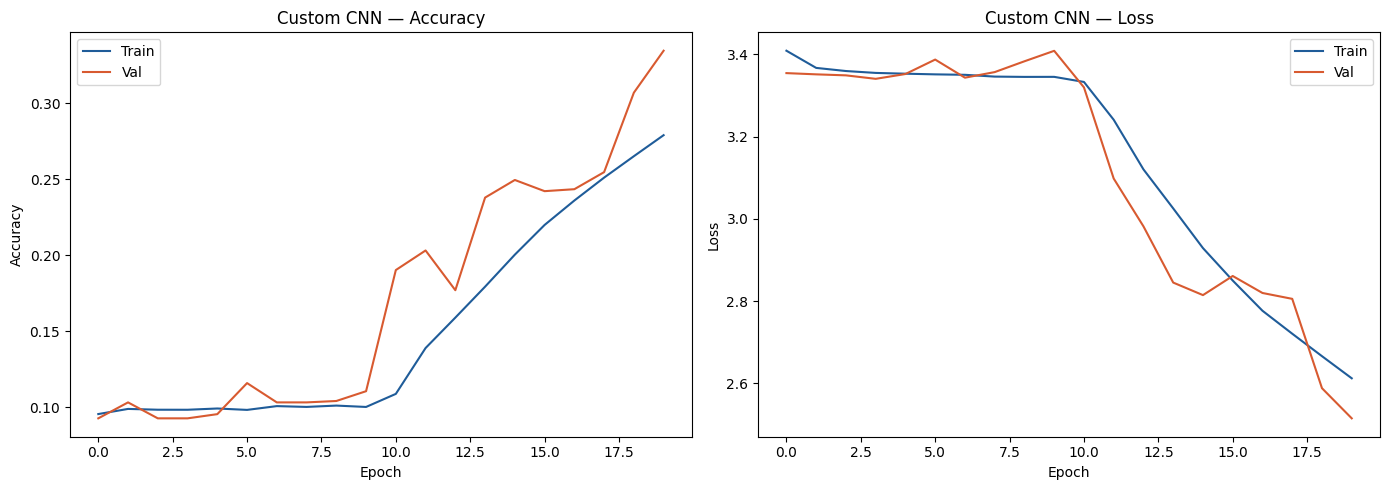


Custom CNN Test Accuracy: 33.26%


In [8]:
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train', color='#1F5C99')
    ax1.plot(history.history['val_accuracy'], label='Val',   color='#d85a30')
    ax1.set_title(f'{model_name} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'],     label='Train', color='#1F5C99')
    ax2.plot(history.history['val_loss'], label='Val',   color='#d85a30')
    ax2.set_title(f'{model_name} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name.replace(' ', '_')}_curves.png", dpi=150)
    plt.show()

plot_history(cnn_history, "Custom CNN")

# Evaluate on test set
cnn_loss, cnn_acc = cnn_model.evaluate(test_ds_final, verbose=0)
print(f"\nCustom CNN Test Accuracy: {cnn_acc*100:.2f}%")

In [9]:
def build_mobilenet(num_classes):
    # Load pretrained MobileNetV2 without the top classifier
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze base model weights
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name="mobilenetv2_transfer")

    return model, base_model

mobilenet_model, base_model = build_mobilenet(NUM_CLASSES)
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 84s 9us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
checkpoint_mn = keras.callbacks.ModelCheckpoint(
    "mobilenet_best.keras", monitor='val_accuracy',
    save_best_only=True, verbose=1)

print("Training MobileNetV2 (frozen base)...")
mn_history = mobilenet_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint_mn],
    verbose=1
)

Training MobileNetV2 (frozen base)...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.1318 - loss: 3.3115
Epoch 1: val_accuracy improved from None to 0.50864, saving model to mobilenet_best.keras

Epoch 1: finished saving model to mobilenet_best.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 271s 195ms/step - accuracy: 0.1551 - loss: 3.1737 - val_accuracy: 0.5086 - val_loss: 1.7419 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.1944 - loss: 2.9605
Epoch 2: val_accuracy improved from 0.50864 to 0.58529, saving model to mobilenet_best.keras

Epoch 2: finished saving model to mobilenet_best.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 335s 204ms/step - accuracy: 0.1991 - loss: 2.9339 - val_accuracy: 0.5853 - val_loss: 1.4175 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.2129 - loss: 2.8510
Epoch 3: val_accuracy improved from 0.58529 to 0.59688, saving model to mobilenet_best.keras

Epoch 3: 

In [11]:
# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning MobileNetV2 (top 30 layers unfrozen)...")
mn_finetune_history = mobilenet_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint_mn],
    verbose=1
)

Fine-tuning MobileNetV2 (top 30 layers unfrozen)...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.1299 - loss: 4.2093
Epoch 1: val_accuracy did not improve from 0.67831
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 366s 260ms/step - accuracy: 0.1631 - loss: 3.4175 - val_accuracy: 0.5562 - val_loss: 1.8649 - learning_rate: 1.0000e-05
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.2102 - loss: 2.8805
Epoch 2: val_accuracy did not improve from 0.67831
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 369s 250ms/step - accuracy: 0.2170 - loss: 2.8585 - val_accuracy: 0.5033 - val_loss: 2.0333 - learning_rate: 1.0000e-05
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.2380 - loss: 2.7446
Epoch 3: val_accuracy did not improve from 0.67831
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 369s 241ms/step - accuracy: 0.2402 - loss: 2.7432 - val_accuracy: 0.5063 - val_loss: 2.0774 - learning_rate: 1.0000e-05
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.25

In [12]:
# Skip fine-tuning — Phase 1 result (67.83%) is already our best
# Just reload the best saved weights
mobilenet_model.load_weights("mobilenet_best.keras")

# Evaluate directly on test set
mn_loss, mn_acc = mobilenet_model.evaluate(test_ds_final, verbose=0)
print(f"\nMobileNetV2 Test Accuracy: {mn_acc*100:.2f}%")

# Final comparison
print("\n" + "="*45)
print("        MODEL COMPARISON SUMMARY")
print("="*45)
print(f"  Logistic Regression : {lr_acc*100:.2f}%")
print(f"  Custom CNN          : {cnn_acc*100:.2f}%")
print(f"  MobileNetV2         : {mn_acc*100:.2f}%")
print("="*45)


MobileNetV2 Test Accuracy: 67.88%

        MODEL COMPARISON SUMMARY
  Logistic Regression : 51.56%
  Custom CNN          : 33.26%
  MobileNetV2         : 67.88%


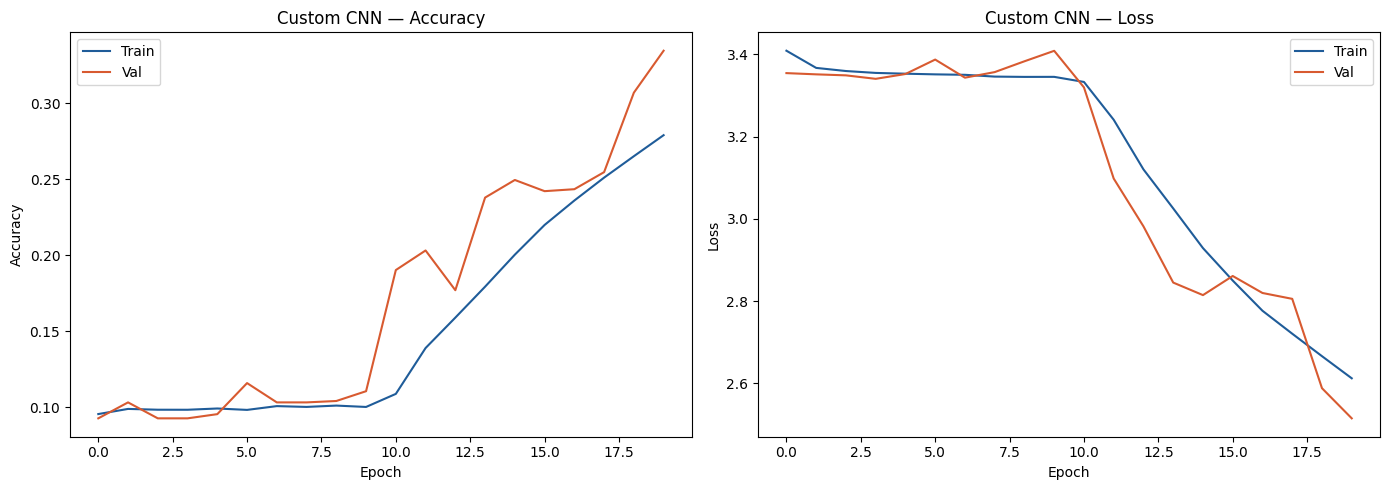

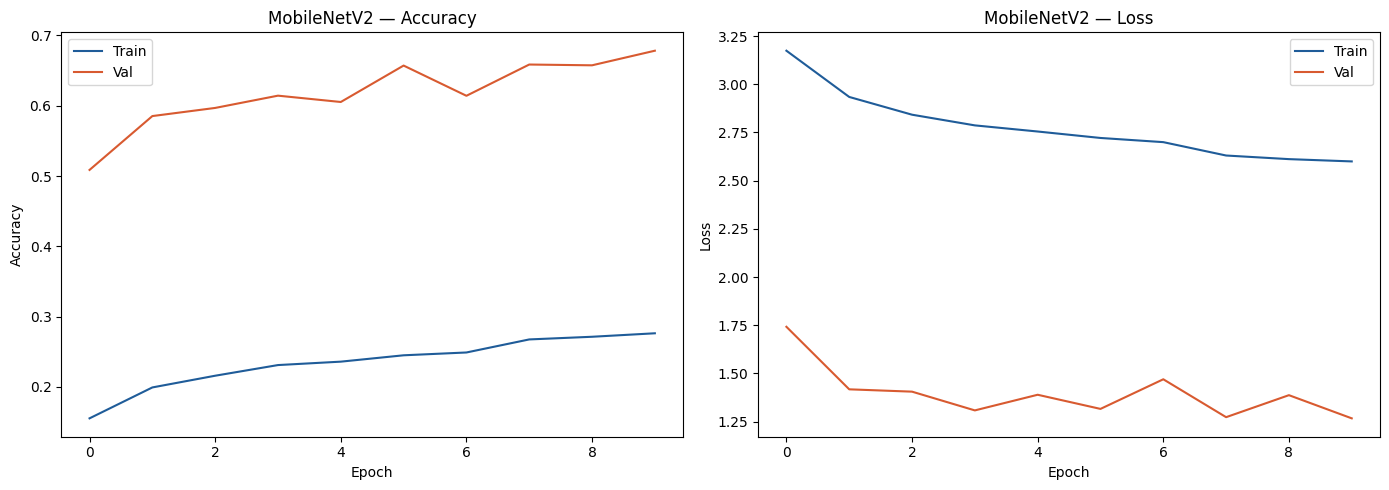

Results saved to model_results.json ✓


In [13]:
plot_history(cnn_history, "Custom CNN")
plot_history(mn_history, "MobileNetV2")

# Save results for Task 5
import json
results = {
    "logistic_regression": round(lr_acc * 100, 2),
    "custom_cnn": round(cnn_acc * 100, 2),
    "mobilenetv2": round(mn_acc * 100, 2)
}
with open("model_results.json", "w") as f:
    json.dump(results, f)

print("Results saved to model_results.json ✓")